In [56]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import joblib
import re
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import sys

from sklearn.model_selection import train_test_split
from plotly.subplots import make_subplots
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.feature_extraction.text import CountVectorizer   # Sac de mots
from sklearn.feature_extraction.text import TfidfVectorizer    # TF-IDF
from sklearn.feature_extraction.text import (
    ENGLISH_STOP_WORDS  #Stop words English
)
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import LinearSVC
import pickle
import nltk
import shutil
import os
import glob
import warnings

import optuna

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, KFold, cross_val_score, RandomizedSearchCV, cross_val_predict
from sklearn.metrics import (
    accuracy_score,  # Précision globale
    precision_score,  # Précision
    recall_score,  # Rappel
    f1_score,  # F1-Score
    confusion_matrix,  # Matrice de confusion
    roc_auc_score,  # AUC (Area Under the Curve)
    roc_curve,  # Courbe ROC
    classification_report,  # Rapport de classification
    mean_squared_error,  # Erreur quadratique moyenne (MSE)
    mean_absolute_error,  # Erreur absolue moyenne (MAE)
    r2_score,  # Coefficient de détermination R²
    auc  # Calcul de l'AUC
)
from sklearn.exceptions import ConvergenceWarning

# Librairies pour LDA
import gensim                    # Modélisation des topics et NLP
from gensim import corpora       # Création du dictionnaire de mots
from gensim.models import LdaModel  # Modèle LDA simple
from gensim.utils import simple_preprocess  # Prétraitement simple des textes
from gensim.models import CoherenceModel    # Calcul de la cohérence des topics
from gensim.models import Phrases           # Création de bigrammes/trigrammes
from gensim.models.phrases import Phraser   # Optimisation bigrammes/trigrammes
from gensim import corpora, models          # Utilisation des modèles
from gensim.models import LdaMulticore      # Modèle LDA parallèle
import multiprocessing                      # Gestion du multi-threading


nltk_data_dir = './nltk_data'


# On laisse au cas où
# # Aggressively clean corrupted NLTK data
# if os.path.exists(nltk_data_dir):
#     shutil.rmtree(nltk_data_dir)
# # Also remove any corrupted zip files from system paths
# for path in nltk.data.path:
#     if os.path.exists(path):
#         for zipfile in glob.glob(os.path.join(path, '*.zip')):
#             try:
#                 os.remove(zipfile)
#             except:
#                 pass

# Create fresh nltk_data directory
os.makedirs(nltk_data_dir, exist_ok=True)
nltk.data.path.insert(0, nltk_data_dir)

# Download resources with fresh start
print("Downloading NLTK resources...")
nltk.download('wordnet', download_dir=nltk_data_dir, quiet=True)
nltk.download('omw-1.4', download_dir=nltk_data_dir, quiet=True)
nltk.download('wordnet_ic', download_dir=nltk_data_dir, quiet=True)
nltk.download('averaged_perceptron_tagger', download_dir=nltk_data_dir, quiet=True)
print("NLTK resources downloaded successfully!")

from nltk.corpus import wordnet
from nltk.stem.snowball import SnowballStemmer

from contraction_fix import fix as expand_contractions # Contraction

NLTK resources downloaded successfully!


In [2]:
import spacy                                # NLP avancé
from spacy import displacy                  # Visualisation
from spacy.cli import download
download("en_core_web_sm")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 73.6 MB/s  0:00:00m0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [3]:
nlp = spacy.load("en_core_web_sm")

In [4]:
df=pd.read_csv('scitweets_export.tsv',
sep='\t')
print (df.head())
print (df.shape)
print (df.columns)

   Unnamed: 0            tweet_id  \
0           0  316669998137483264   
1           1  319090866545385472   
2           2  322030931022065664   
3           3  322694830620807168   
4           4  328524426658328576   

                                                text  science_related  \
0  Knees are a bit sore. i guess that's a sign th...                0   
1          McDonald's breakfast stop then the gym 🏀💪                0   
2  Can any Gynecologist with Cancer Experience ex...                1   
3  Couch-lock highs lead to sleeping in the couch...                1   
4  Does daily routine help prevent problems with ...                1   

   scientific_claim  scientific_reference  scientific_context  
0               0.0                   0.0                 0.0  
1               0.0                   0.0                 0.0  
2               1.0                   0.0                 0.0  
3               1.0                   0.0                 0.0  
4               1.

In [5]:
def stop_words(text):
    # Normalisation simple des apostrophes typographiques
    text = text.replace("’", "'")
    tokens = text.split()
    expanded = []
    for t in tokens:
        key = t.lower()
        if key not in ENGLISH_STOP_WORDS:
            expanded.append(t)
    return " ".join(expanded)

text = "I'm happy but I don't know why."
print(text)
print(stop_words(expand_contractions(text)))

I'm happy but I don't know why.
happy know why.


In [6]:
stemmer = nltk.stem.porter.PorterStemmer()
lemmatizer = nltk.stem.WordNetLemmatizer()

def stemmerLemma(text):
    # Normalisation simple des apostrophes typographiques
    text = text.replace("’", "'")
    expanded = []
    t2 = nlp(text)
    
    for t in t2:
        
        key = t.text.lower()
        # print(key, t.pos_, stemmer.stem(key), lemmatizer.lemmatize(key))
        if t.pos_ == "VERB":
            result = stemmer.stem(key)
        elif t.pos_ == "NOUN" or t.pos_ == "ADJ" or t.pos_ == "PROPN":
            result = lemmatizer.lemmatize(key)
        else:
            result = key
        expanded.append(result)
    return " ".join(expanded)

print(df.text[3])
print(stemmerLemma(df.text[3]))
text = "I want this cake"
print(stop_words(stemmerLemma(text)))
print(stemmerLemma("I am running"))

Couch-lock highs lead to sleeping in the couch. Gotta stop doing this shit.
couch - lock high lead to sleep in the couch . got ta stop do this shit .
want cake
i am run


In [7]:
emoticons_str = r"""
    (?:
        [:=;] # Eyes
        [oO\-]? # Nose (optional)
        [D\)\]\(\]/\\OpP] # Mouth
    )"""
html_str = r"<[^>]+>"
mentions_str = r"(?:@[\w_]+)"
hashtags_str = r"(?:\#+[\w_]+[\w\'_\-]*[\w_]+)"
url_str = r"http[s]?://(?:[a-z]|[0-9]|[$-_@.&amp;+]|[!*\(\),]|(?:%[0-9a-f][0-9a-f]))+"
number_str = r"(?:(?:\d+,?)+(?:\.?\d+)?)"
compose_str = r"(?:[a-z][a-z'\-_]+[a-z])"
mots_str = r"(?:[\w_]+)"
reste_str = r"(?:[\S]+)"

total_str = [
    emoticons_str,
    html_str,
    mentions_str,
    hashtags_str,
    url_str,
    number_str,
    compose_str,
    mots_str,
    reste_str,
]

emoticons_regex = re.compile(emoticons_str, re.VERBOSE | re.IGNORECASE)
html_regex = re.compile(html_str, re.VERBOSE | re.IGNORECASE)
mentions_regex = re.compile(mentions_str, re.VERBOSE | re.IGNORECASE)
hashtags_regex = re.compile(hashtags_str, re.VERBOSE | re.IGNORECASE)
url_regex = re.compile(url_str, re.VERBOSE | re.IGNORECASE)
number_regex = re.compile(number_str, re.VERBOSE | re.IGNORECASE)
compose_regex = re.compile(compose_str, re.VERBOSE | re.IGNORECASE)
mots_regex = re.compile(mots_str, re.VERBOSE | re.IGNORECASE)
reste_regex = re.compile(reste_str, re.VERBOSE | re.IGNORECASE)
total_regex = re.compile(r'('+'|'.join(total_str)+')', re.VERBOSE | re.IGNORECASE)

def preprocess(s, emoticons=False, html=False, mentions=False, hashtags=False, url=False, number=False, compose=True,
               stemmerlemma=True, stopwords=True):
    tokens = total_regex.findall(s)

    tokens = [tok for tok in tokens if 
        mots_regex.search(tok) and # TODO: fix
        (emoticons or not emoticons_regex.search(tok)) and
        (html or not html_regex.search(tok)) and
        (mentions or not mentions_regex.search(tok)) and
        (hashtags or not hashtags_regex.search(tok)) and
        (url or not url_regex.search(tok)) and
        (number or not number_regex.search(tok)) and
        (compose or not compose_regex.search(tok))
    ]
            
    sentence = " ".join(tokens)
    if stemmerlemma:
        sentence = stemmerLemma(sentence)
    if stopwords:
        sentence = stop_words(sentence)
        
    return sentence

preprocess("This is an example, ! of #CountVectorizer for creating a vector https://leotta.ro 런쥔을공평하게_대하세요")
# print(preprocess("This is another example of CountVectorizer"))
# print(preprocess("with or without parameters"))

'example creat vector 런쥔을공평하게_대하세요'

# 2 – Classification

Features : ['aamiin' 'aap' 'ab' ... 'ᵀᴴᴵˢ' 'ᵞᴼᵁ' 'ᶜᴴᴬᴿᴬᶜᵀᴱᴿ']
Tout est converti en minuscules (on peut mettre lowercase=False)

      aamiin  aap  ab  abah  abc  abdi  abeg  abetz  ability  able  ...  özil  \
0          0    0   0     0    0     0     0      0        0     0  ...     0   
1          0    0   0     0    0     0     0      0        0     0  ...     0   
2          0    0   0     0    0     0     0      0        0     0  ...     0   
3          0    0   0     0    0     0     0      0        0     0  ...     0   
4          0    0   0     0    0     0     0      0        0     0  ...     0   
...      ...  ...  ..   ...  ...   ...   ...    ...      ...   ...  ...   ...   
1135       0    0   0     0    0     0     0      0        0     0  ...     0   
1136       0    0   0     0    0     0     0      0        0     0  ...     0   
1137       0    0   0     0    0     0     0      0        0     0  ...     0   
1138       0    0   0     0    0     0     0      0        0  

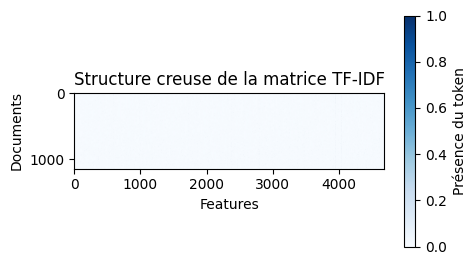

'fifth u high school student use tobacco survey'

In [8]:
# Vectorisation par defaut (lowercase=True)
vectorizer = CountVectorizer()
X = vectorizer.fit_transform([preprocess(t) for t in df.text])

# Affichage des features et du vocabulaire
print("Features :", vectorizer.get_feature_names_out())
print("Tout est converti en minuscules (on peut mettre lowercase=False)\n")

# création du dataframe pour affichage
dfvec = pd.DataFrame(
    data=X.toarray(),  # Utilisation directe de X
    columns=vectorizer.get_feature_names_out()  # get_feature_names_out()
)

print(dfvec)

M_tfidf = X.toarray()
plt.figure(figsize=(5, 3))
plt.imshow(M_tfidf > 0, cmap="Blues")   # bleu = valeur non nulle, gris = zéro
plt.title("Structure creuse de la matrice TF-IDF")
plt.xlabel("Features")
plt.ylabel("Documents")
plt.colorbar(label="Présence du token")
plt.show()
preprocess(df.text[198])

In [9]:
text = [preprocess(t, url=False, hashtags=False, mentions=False) for t in df.text]

# TF-IDF avec normalisation (par défaut)
print("TF-IDF normalisé :\n")

vectorizer_norm = TfidfVectorizer()   # norm='l2' par défaut
X_norm = vectorizer_norm.fit_transform(text)

df_norm = pd.DataFrame(
    X_norm.toarray(),
    columns=vectorizer_norm.get_feature_names_out()
)
print(df_norm)
print()

# Normes des vecteurs normalisés : elles doivent toutes valoir 1
print("Normes L2 avec normalisation (norme = 1 pour chaque document) :")
normes_norm = np.linalg.norm(X_norm.toarray(), axis=1)
print(normes_norm)
print()

# TF-IDF sans normalisation
print("TF-IDF sans normalisation :\n")

vectorizer_raw = TfidfVectorizer(norm=None)   # désactivation explicite
X_raw = vectorizer_raw.fit_transform(text)

df_raw = pd.DataFrame(
    X_raw.toarray(),
    columns=vectorizer_raw.get_feature_names_out()
)
print(df_raw)
print()

# Normes des vecteurs non normalisés
# Chaque document correspond à un vecteur TF-IDF. Sans normalisation,
# leur longueur (norme L2) dépend de la taille et du contenu du document.
print("Normes L2 des vecteurs TF-IDF (sans normalisation) :")
normes_raw = np.linalg.norm(X_raw.toarray(), axis=1)
print(normes_raw)

TF-IDF normalisé :

      aamiin  aap   ab  abah  abc  abdi  abeg  abetz  ability  able  ...  \
0        0.0  0.0  0.0   0.0  0.0   0.0   0.0    0.0      0.0   0.0  ...   
1        0.0  0.0  0.0   0.0  0.0   0.0   0.0    0.0      0.0   0.0  ...   
2        0.0  0.0  0.0   0.0  0.0   0.0   0.0    0.0      0.0   0.0  ...   
3        0.0  0.0  0.0   0.0  0.0   0.0   0.0    0.0      0.0   0.0  ...   
4        0.0  0.0  0.0   0.0  0.0   0.0   0.0    0.0      0.0   0.0  ...   
...      ...  ...  ...   ...  ...   ...   ...    ...      ...   ...  ...   
1135     0.0  0.0  0.0   0.0  0.0   0.0   0.0    0.0      0.0   0.0  ...   
1136     0.0  0.0  0.0   0.0  0.0   0.0   0.0    0.0      0.0   0.0  ...   
1137     0.0  0.0  0.0   0.0  0.0   0.0   0.0    0.0      0.0   0.0  ...   
1138     0.0  0.0  0.0   0.0  0.0   0.0   0.0    0.0      0.0   0.0  ...   
1139     0.0  0.0  0.0   0.0  0.0   0.0   0.0    0.0      0.0   0.0  ...   

      özil  ᴬᴳᴬᴵᴺ  ᴶᴼᴷᴱˢ  ᴸᴵᴱᴰ  ᴸᴼᵛᴱ   ᴼᴺ  ᴼᴼᴴ  ᵀᴴᴵˢ  ᵞᴼᵁ  ᶜᴴᴬᴿᴬᶜᵀᴱ

In [10]:
# y = df["science_related"]

# pipe = Pipeline([
#     ("vectorizer", TfidfVectorizer(lowercase=False, ngram_range=(1, 2))),
#     #("SVM", SVC(kernel="linear"))
#     ("model", LinearSVC())
# ])

# texte = [preprocess(t) for t in df.text]
# X_transformed = pipe.fit(texte, y)

# print("Apprentissage terminé sur l'ensemble du corpus.")

# '''df_pipe = pd.DataFrame(
#     data=X_transformed.toarray(),  # Utilisation directe de X
#     columns=pipe["vectorizer"].get_feature_names_out()
# )'''


# new_review = "salut child labour cancer"
# new_review = preprocess(new_review)

# # Prédiction
# prediction = pipe.predict([new_review])[0]

# print("Avis :", new_review)
# print("Prédiction :", prediction)



# Génération et test du model

In [76]:
# 1. Séparation en 2 DataFrames (votre idée)
df_0 = df[df["science_related"] == 0]
df_1 = df[df["science_related"] == 1]

# 2. On récupère le nombre de lignes de la classe minoritaire (les 1)
nb_lignes_1 = len(df_1)

# 3. On pioche au hasard le même nombre de lignes dans les 0
# random_state=42 permet de bloquer le hasard pour avoir toujours le même résultat
df_0_sous_echantillonne = df_0.sample(n=nb_lignes_1, random_state=42)

# 4. On fusionne les deux morceaux dans un nouveau DataFrame
df_equilibre = pd.concat([df_1, df_0_sous_echantillonne])

# 5. Optionnel : On mélange les lignes pour ne pas avoir tous les 1 puis tous les 0
df_equilibre = df_equilibre.sample(frac=1, random_state=42).reset_index(drop=True)

# Vérification
print(df_equilibre["science_related"].value_counts())

science_related
0    375
1    375
Name: count, dtype: int64


In [79]:
texte = [preprocess(t) for t in df_equilibre.text]
pipe = Pipeline([
    ("vectorizer", TfidfVectorizer(lowercase=False, ngram_range=(1, 2))),
    #("SVM", SVC(kernel="linear"))
    ("model", LinearSVC())
])

X_train_related, X_test_related, y_train_related, y_test_related = train_test_split(
    texte, df_equilibre["science_related"], test_size=0.2, stratify=df_equilibre["science_related"], random_state=42
)

In [81]:
models = []
models.append(("KNN", KNeighborsClassifier()))
models.append(("DecisionTree", DecisionTreeClassifier()))
models.append(("GaussianNB", GaussianNB()))
models.append(("LinearSVC", LinearSVC()))
models.append(("RandomForest", RandomForestClassifier()))

pipes= []

results = []
names = []
seed = 42

x_claims = df_equilibre["text"]
y_science_related = df_equilibre["science_related"]

for name, model in models:
    kfold = KFold(n_splits=10, random_state=seed, shuffle=True)
    vectorizer = TfidfVectorizer(lowercase=False, ngram_range=(1, 2))
    X = vectorizer.fit_transform([preprocess(t) for t in x_claims]).toarray()
    cv_results = cross_val_score(
        model, X, y_science_related, cv=kfold, scoring="accuracy"
    )
    results.append(cv_results)
    names.append(name)
    msg = "%s: %0.4f (%0.4f)" % (name, cv_results.mean(), cv_results.std())
    print(msg)
    pipes.append(Pipeline([("vectorizer", vectorizer), ("model", model)]))
    conf = confusion_matrix(y_test_related, y_pred)
    print("\nMatrice de confusion\n", conf)
    print("\nClassification report\n",
        classification_report(y_test_related, y_pred))

KNN: 0.6760 (0.0617)


ValueError: Found input variables with inconsistent numbers of samples: [150, 1140, 150]

Début de l'évaluation des modèles...

--------------- Modèle : KNN ---------------
Accuracy Moyenne : 0.7096 (Ecart-type: 0.0246)

Matrice de confusion :

Classification report :
              precision    recall  f1-score   support

           0       0.80      0.75      0.78       765
           1       0.55      0.63      0.59       375

    accuracy                           0.71      1140
   macro avg       0.68      0.69      0.68      1140
weighted avg       0.72      0.71      0.71      1140






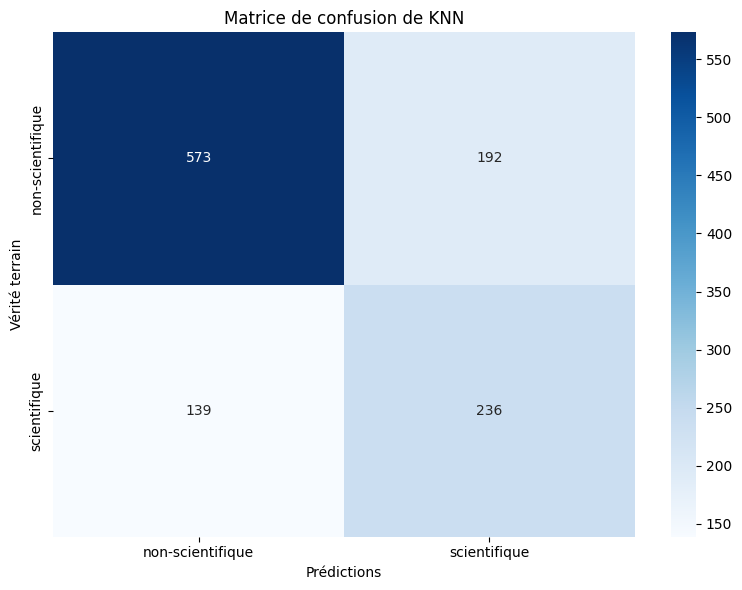

--------------- Modèle : DecisionTree ---------------
Accuracy Moyenne : 0.7430 (Ecart-type: 0.0400)

Matrice de confusion :

Classification report :
              precision    recall  f1-score   support

           0       0.83      0.76      0.80       765
           1       0.59      0.69      0.63       375

    accuracy                           0.74      1140
   macro avg       0.71      0.73      0.72      1140
weighted avg       0.75      0.74      0.74      1140






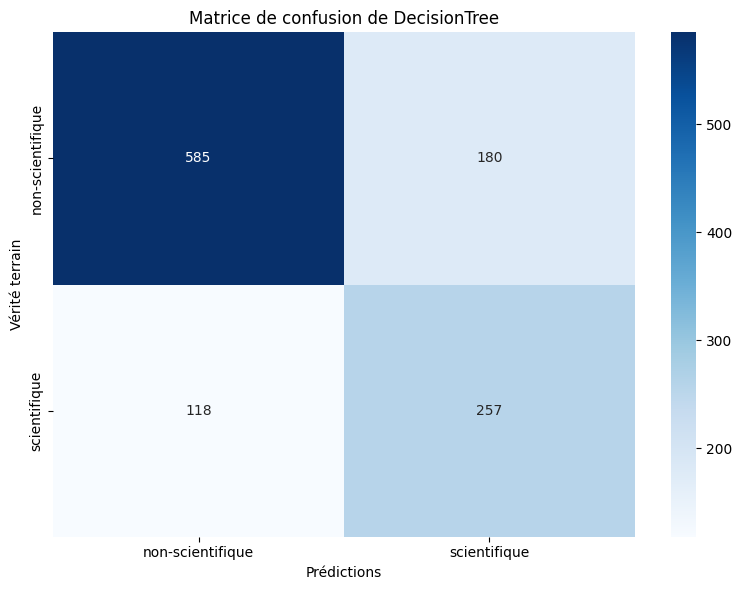

--------------- Modèle : MultinomialNB ---------------
Accuracy Moyenne : 0.7123 (Ecart-type: 0.0459)

Matrice de confusion :

Classification report :
              precision    recall  f1-score   support

           0       0.70      0.99      0.82       765
           1       0.93      0.14      0.24       375

    accuracy                           0.71      1140
   macro avg       0.81      0.57      0.53      1140
weighted avg       0.78      0.71      0.63      1140






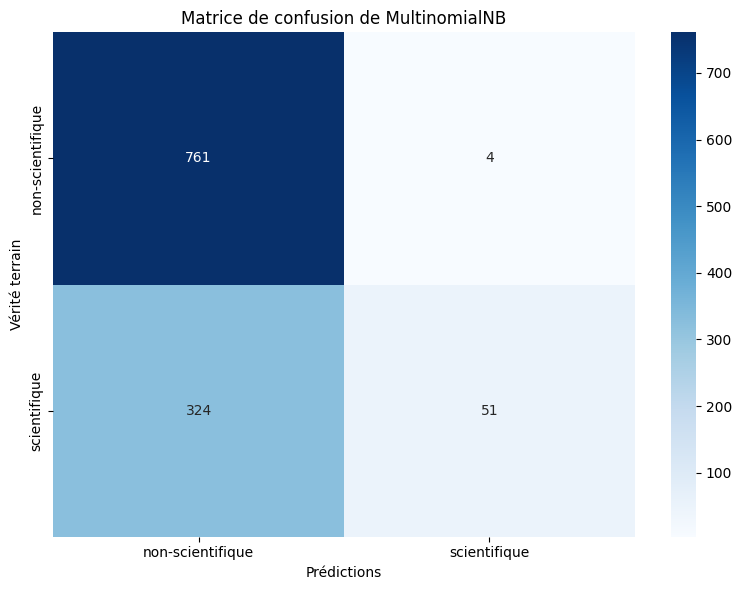

--------------- Modèle : LinearSVC ---------------
Accuracy Moyenne : 0.8061 (Ecart-type: 0.0414)

Matrice de confusion :

Classification report :
              precision    recall  f1-score   support

           0       0.82      0.92      0.86       765
           1       0.78      0.58      0.66       375

    accuracy                           0.81      1140
   macro avg       0.80      0.75      0.76      1140
weighted avg       0.80      0.81      0.80      1140






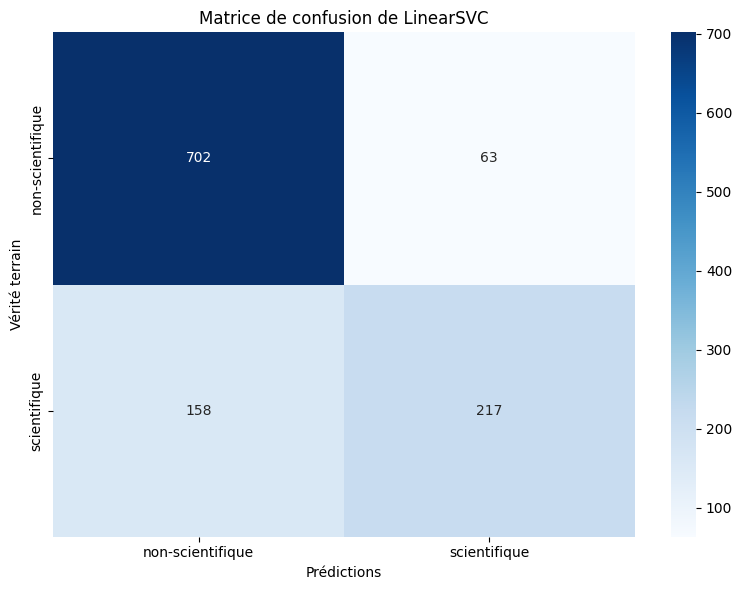

--------------- Modèle : RandomForest ---------------
Accuracy Moyenne : 0.7728 (Ecart-type: 0.0377)

Matrice de confusion :

Classification report :
              precision    recall  f1-score   support

           0       0.83      0.84      0.83       765
           1       0.66      0.64      0.65       375

    accuracy                           0.77      1140
   macro avg       0.74      0.74      0.74      1140
weighted avg       0.77      0.77      0.77      1140






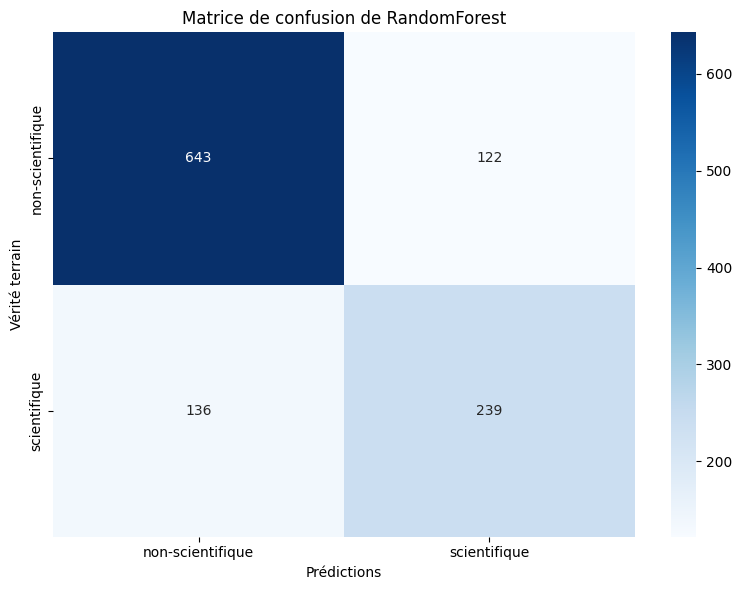

In [64]:
# import pandas as pd
# from sklearn.model_selection import KFold, cross_val_score, cross_val_predict
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.pipeline import Pipeline
# from sklearn.metrics import confusion_matrix, classification_report
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.naive_bayes import MultinomialNB # Remplaçant idéal de GaussianNB pour le texte
# from sklearn.svm import LinearSVC
# from sklearn.ensemble import RandomForestClassifier

# 1. Préparation de tes données textuelles brutes
X_raw = [preprocess(t) for t in df["text"]]
y = df["science_related"]

# 2. Liste de tes modèles (sans GaussianNB, remplacé par MultinomialNB)
models = [
    ("KNN", KNeighborsClassifier()),
    ("DecisionTree", DecisionTreeClassifier()),
    ("MultinomialNB", MultinomialNB()),
    ("LinearSVC", LinearSVC()),
    ("RandomForest", RandomForestClassifier())
]

seed = 42
kfold = KFold(n_splits=10, random_state=seed, shuffle=True)

# Pour stocker les modèles finaux si besoin
pipes = []

print("Début de l'évaluation des modèles...\n")

for name, model in models:
    print(f"{"-"*15} Modèle : {name} {"-"*15}")
    
    # ÉTAPE CLÉ : Le Pipeline. 
    # À chaque tour de validation croisée, il va vectoriser UNIQUEMENT sur le train set,
    # puis prédire sur le test set. Zéro fuite de données !
    pipeline = Pipeline([
        ("vectorizer", TfidfVectorizer(lowercase=False, ngram_range=(1, 2))),
        ("model", model)
    ])
    
    # Calcul de l'accuracy moyenne pour ce modèle
    cv_results = cross_val_score(pipeline, X_raw, y, cv=kfold, scoring="accuracy")
    print(f"Accuracy Moyenne : {cv_results.mean():.4f} (Ecart-type: {cv_results.std():.4f})")
    
    # Génération des prédictions "out-of-fold" pour générer les rapports
    y_pred = cross_val_predict(pipeline, X_raw, y, cv=kfold)
    
    # Affichage des statistiques détaillées
    print("\nMatrice de confusion :")
    confusion_matrix(y, y_pred)
    
    print("\nClassification report :")
    print(classification_report(y, y_pred))
    print("\n\n")
    
    conf_matrix_balanced = confusion_matrix(y, y_pred)
    labels = ["non-scientifique", "scientifique"]
    plot_confusion_matrix(conf_matrix_balanced, labels, title=("Matrice de confusion de " + name))

    pipes.append((name, pipeline))

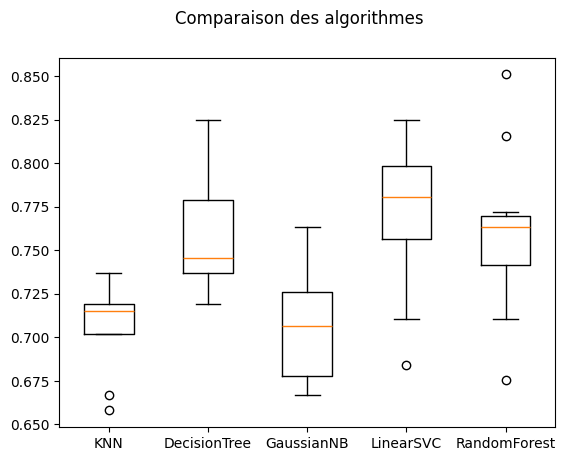

In [30]:
fig = plt.figure()
fig.suptitle("Comparaison des algorithmes")
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.show()

In [ ]:
# --- 1. Création de la Pipeline ---
pipe = Pipeline([
    ("vectorizer", TfidfVectorizer(lowercase=False)),
    ("model", RandomForestClassifier(random_state=42))
])

# --- 2. Définition des hyperparamètres ---
# On fusionne en un seul dictionnaire car le Random Forest n'a pas de conflits de paramètres comme le LinearSVC (l1 vs l2)
params = {
    "model__n_estimators": [4, 6, 9],
    "model__max_features": ["log2", "sqrt"],
    "model__criterion": ["entropy", "gini"],
    "model__max_depth": [2, 3, 5, 10],
    "model__min_samples_split": [2, 3, 5],
    "model__min_samples_leaf": [1, 5, 8],
    
    "vectorizer__ngram_range": [(1,1), (1,2), (1,3)],
    "vectorizer__max_features": [3000, 5000, 10000],
    "vectorizer__min_df": [2, 5, 10],
    "vectorizer__max_df": [0.85, 0.95],
}

# --- 3. Configuration de la validation croisée ---
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

grid = GridSearchCV(
    pipe, 
    params,
    cv=cv,
    scoring="f1_weighted",
    return_train_score=True,
    n_jobs=-1
)

# --- 4. Entraînement ---
# Plus besoin du filtre ConvergenceWarning, il n'est pas utilisé par Random Forest
grid.fit(X_train_related, y_train_related)

# --- 5. Diagnostic d'Overfitting ---
results = pd.DataFrame(grid.cv_results_)
train_score = results.loc[grid.best_index_, "mean_train_score"]
val_score   = grid.best_score_
gap         = train_score - val_score

print("Meilleurs paramètres :", grid.best_params_)
print(f"Train score:      {train_score:.4f}")
print(f"Validation score: {val_score:.4f}")
print(f"Overfitting gap:  {gap:.4f}", "⚠️ possible overfit" if gap > 0.1 else "✅ looks healthy")

# --- 6. Évaluation Finale ---
test_score = grid.score(X_test_related, y_test_related)
print(f"\nTest score (held-out): {test_score:.4f}")
print(classification_report(y_test_related, grid.predict(X_test_related)))

# La précision mesure la proportion de prédictions positives correctes parmi toutes les prédictions positives faites par le modèle

Meilleurs paramètres : {'model__criterion': 'gini', 'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 9, 'vectorizer__max_df': 0.85, 'vectorizer__max_features': 3000, 'vectorizer__min_df': 10, 'vectorizer__ngram_range': (1, 1)}
Train score:      0.7394
Validation score: 0.6808
Overfitting gap:  0.0586 ✅ looks healthy

Test score (held-out): 0.7198
              precision    recall  f1-score   support

           0       0.74      0.97      0.84       153
           1       0.86      0.32      0.47        75

    accuracy                           0.76       228
   macro avg       0.80      0.65      0.66       228
weighted avg       0.78      0.76      0.72       228



In [66]:
# --- 1. Création de la Pipeline ---
pipe = Pipeline(
    [
        ("vectorizer", TfidfVectorizer(lowercase=False)),
        (
            "model",
            RandomForestClassifier(random_state=42),
        ),  # <--- CHANGEMENT DU MODÈLE ICI
    ]
)

# (Je pars du principe que X_train_related, etc. sont déjà créés avec votre train_test_split original)

# --- 2. Définition des hyperparamètres ---
# On fusionne en un seul dictionnaire car le Random Forest n'a pas de conflits de paramètres comme le LinearSVC (l1 vs l2)
params = {
    # Paramètres spécifiques au Random Forest
    "model__n_estimators": [4, 6, 9],
    "model__max_features": ["log2", "sqrt"],
    "model__criterion": ["entropy", "gini"],
    "model__max_depth": [2, 3, 5, 10, 15, 20],
    "model__min_samples_split": [2, 3, 5],
    "model__min_samples_leaf": [1, 5, 8],
    # Paramètres du TfidfVectorizer (conservés à l'identique)
    "vectorizer__ngram_range": [(1, 1), (1, 2), (1, 3)],
    "vectorizer__max_features": [3000, 5000, 10000],
    "vectorizer__min_df": [2, 5, 10],
    "vectorizer__max_df": [0.85, 0.95],
}

# --- 3. Configuration de la validation croisée ---
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

grid = RandomizedSearchCV(
    pipe,
    params,
    n_iter=1000,   # au lieu de 23328 combinaisons
    cv=cv,
    scoring="f1_weighted",
    n_jobs=-1,
    random_state=42,
    return_train_score=True
)


# --- 4. Entraînement ---
# Plus besoin du filtre ConvergenceWarning, il n'est pas utilisé par Random Forest
grid.fit(X_train_related, y_train_related)

# --- 5. Diagnostic d'Overfitting ---
results = pd.DataFrame(grid.cv_results_)
train_score = results.loc[grid.best_index_, "mean_train_score"]
val_score = grid.best_score_
gap = train_score - val_score

print("Meilleurs paramètres :", grid.best_params_)
print(f"Train score:      {train_score:.4f}")
print(f"Validation score: {val_score:.4f}")
print(
    f"Overfitting gap:  {gap:.4f}",
    "⚠️ possible overfit" if gap > 0.1 else "✅ looks healthy",
)

# --- 6. Évaluation Finale ---
test_score = grid.score(X_test_related, y_test_related)
print(f"\nTest score (held-out): {test_score:.4f}")
print(classification_report(y_test_related, grid.predict(X_test_related)))

# La précision mesure la proportion de prédictions positives correctes parmi toutes les prédictions positives faites par le modèle

Meilleurs paramètres : {'vectorizer__ngram_range': (1, 2), 'vectorizer__min_df': 10, 'vectorizer__max_features': 10000, 'vectorizer__max_df': 0.85, 'model__n_estimators': 9, 'model__min_samples_split': 3, 'model__min_samples_leaf': 1, 'model__max_features': 'log2', 'model__max_depth': 20, 'model__criterion': 'entropy'}
Train score:      0.7963
Validation score: 0.7096
Overfitting gap:  0.0867 ✅ looks healthy

Test score (held-out): 0.7024
              precision    recall  f1-score   support

           0       0.74      0.95      0.83       153
           1       0.77      0.31      0.44        75

    accuracy                           0.74       228
   macro avg       0.75      0.63      0.64       228
weighted avg       0.75      0.74      0.70       228



In [ ]:
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV
from joblib import Memory

# import pandas as pd

# =========================================================
# 1. Cache du pipeline (accélère fortement le TF-IDF)
# =========================================================

memory = Memory("./cache_dir", verbose=0)

# =========================================================
# 2. Pipeline
# =========================================================

pipe = Pipeline(
    [
        ("vectorizer", TfidfVectorizer(lowercase=False)),
        ("model", RandomForestClassifier(random_state=42, n_jobs=-1)),
    ],
    memory=memory,
)

# =========================================================
# 3. Hyperparamètres
# (version réduite et plus réaliste)
# =========================================================

params = {
    # Random Forest
    "model__n_estimators": [50, 100],
    "model__max_features": ["sqrt"],
    "model__criterion": ["gini", "entropy"],
    "model__max_depth": [5, 10, None],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
    # TF-IDF
    "vectorizer__ngram_range": [(1, 1), (1, 2)],
    "vectorizer__max_features": [3000, 5000],
    "vectorizer__min_df": [2, 5],
    "vectorizer__max_df": [0.85, 0.95],
}

# =========================================================
# 4. Validation croisée
# =========================================================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# =========================================================
# 5. Halving Grid Search
# =========================================================

grid = HalvingGridSearchCV(
    estimator=pipe,
    param_grid=params,
    # métrique
    scoring="f1_weighted",
    # CV
    cv=cv,
    # parallélisation
    n_jobs=-1,
    # stratégie halving
    factor=3,  # élimine ~2/3 des modèles à chaque étape
    resource="n_samples",
    max_resources="auto",
    # diagnostics
    verbose=2,
    # reproductibilité
    random_state=42,
)

# =========================================================
# 6. Entraînement
# =========================================================

grid.fit(X_train_related, y_train_related)

# =========================================================
# 7. Résultats
# =========================================================

results = pd.DataFrame(grid.cv_results_)

train_score = results.loc[grid.best_index_, "mean_train_score"]
val_score = grid.best_score_
gap = train_score - val_score

print("\n==============================")
print("Meilleurs paramètres")
print("==============================")
print(grid.best_params_)

print(f"\nTrain score:      {train_score:.4f}")
print(f"Validation score: {val_score:.4f}")
print(
    f"Overfitting gap:  {gap:.4f}",
    "⚠️ possible overfit" if gap > 0.1 else "✅ looks healthy",
)

# =========================================================
# =========================================================

test_score = grid.score(X_test_related, y_test_related)

print(f"\nTest score (held-out): {test_score:.4f}")

y_pred = grid.predict(X_test_related)

print("\nClassification Report")
print(classification_report(y_test_related, y_pred))

n_iterations: 4
n_required_iterations: 7
n_possible_iterations: 4
min_resources_: 20
max_resources_: 912
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 768
n_resources: 20
Fitting 5 folds for each of 768 candidates, totalling 3840 fits
[CV] END model__criterion=gini, model__max_depth=5, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=50, vectorizer__max_df=0.85, vectorizer__max_features=3000, vectorizer__min_df=5, vectorizer__ngram_range=(1, 1); total time=   0.0s
[CV] END model__criterion=gini, model__max_depth=5, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=50, vectorizer__max_df=0.85, vectorizer__max_features=3000, vectorizer__min_df=5, vectorizer__ngram_range=(1, 2); total time=   0.0s
[CV] END model__criterion=gini, model__max_depth=5, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=50, vectorize

/home/troutfario/gits/MachineLearningProjectdefou/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:490: FitFailedWarning: 
1536 fits failed out of a total of 3840.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1536 fits failed with the following error:
Traceback (most recent call last):
  File "/home/troutfario/gits/MachineLearningProjectdefou/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/troutfario/gits/MachineLearningProjectdefou/.venv/lib/python3.12/site-packages/sklearn/base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^

[CV] END model__criterion=gini, model__max_depth=None, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=5, model__n_estimators=50, vectorizer__max_df=0.95, vectorizer__max_features=5000, vectorizer__min_df=2, vectorizer__ngram_range=(1, 2); total time=   0.1s
[CV] END model__criterion=gini, model__max_depth=None, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=5, model__n_estimators=50, vectorizer__max_df=0.95, vectorizer__max_features=3000, vectorizer__min_df=2, vectorizer__ngram_range=(1, 1); total time=   0.1s
[CV] END model__criterion=gini, model__max_depth=None, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=5, model__n_estimators=50, vectorizer__max_df=0.95, vectorizer__max_features=3000, vectorizer__min_df=2, vectorizer__ngram_range=(1, 2); total time=   0.1s
[CV] END model__criterion=entropy, model__max_depth=None, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_spl

/home/troutfario/gits/MachineLearningProjectdefou/.venv/lib/python3.12/site-packages/sklearn/model_selection/_search.py:1137: UserWarning: One or more of the test scores are non-finite: [0.62666667 0.62666667        nan ... 0.59365413 0.54689375 0.61883309]
  warnings.warn(
/home/troutfario/gits/MachineLearningProjectdefou/.venv/lib/python3.12/site-packages/sklearn/model_selection/_search.py:1137: UserWarning: One or more of the train scores are non-finite: [0.88795881 0.88795881        nan ... 0.86544206 0.76771403 0.86544206]
  warnings.warn(


----------
iter: 2
n_candidates: 86
n_resources: 180
Fitting 5 folds for each of 86 candidates, totalling 430 fits
[CV] END model__criterion=gini, model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=5, model__n_estimators=100, vectorizer__max_df=0.95, vectorizer__max_features=5000, vectorizer__min_df=2, vectorizer__ngram_range=(1, 2); total time=   0.2s
[CV] END model__criterion=gini, model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=5, model__n_estimators=100, vectorizer__max_df=0.85, vectorizer__max_features=5000, vectorizer__min_df=2, vectorizer__ngram_range=(1, 2); total time=   0.2s
[CV] END model__criterion=gini, model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=2, model__n_estimators=100, vectorizer__max_df=0.95, vectorizer__max_features=5000, vectorizer__min_df=2, vectorizer__ngram_range=(1, 2); total time=   0.2s
[CV] END model__crite

/home/troutfario/gits/MachineLearningProjectdefou/.venv/lib/python3.12/site-packages/sklearn/model_selection/_search.py:1137: UserWarning: One or more of the test scores are non-finite: [0.62666667 0.62666667        nan ... 0.63164291 0.63164291 0.62264005]
  warnings.warn(
/home/troutfario/gits/MachineLearningProjectdefou/.venv/lib/python3.12/site-packages/sklearn/model_selection/_search.py:1137: UserWarning: One or more of the train scores are non-finite: [0.88795881 0.88795881        nan ... 0.82076526 0.82076526 0.80770639]
  warnings.warn(


[CV] END model__criterion=entropy, model__max_depth=None, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=5, model__n_estimators=50, vectorizer__max_df=0.85, vectorizer__max_features=3000, vectorizer__min_df=2, vectorizer__ngram_range=(1, 1); total time=   0.2s
[CV] END model__criterion=gini, model__max_depth=None, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=2, model__n_estimators=100, vectorizer__max_df=0.85, vectorizer__max_features=3000, vectorizer__min_df=2, vectorizer__ngram_range=(1, 2); total time=   0.2s
[CV] END model__criterion=entropy, model__max_depth=None, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=5, model__n_estimators=50, vectorizer__max_df=0.85, vectorizer__max_features=3000, vectorizer__min_df=2, vectorizer__ngram_range=(1, 1); total time=   0.2s
[CV] END model__criterion=gini, model__max_depth=None, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples

/home/troutfario/gits/MachineLearningProjectdefou/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/troutfario/gits/MachineLearningProjectdefou/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/troutfario/gits/MachineLearningProjectdefou/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib 

[CV] END model__criterion=gini, model__max_depth=None, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=5, model__n_estimators=50, vectorizer__max_df=0.85, vectorizer__max_features=5000, vectorizer__min_df=2, vectorizer__ngram_range=(1, 1); total time=   0.2s
[CV] END model__criterion=entropy, model__max_depth=None, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=5, model__n_estimators=50, vectorizer__max_df=0.95, vectorizer__max_features=5000, vectorizer__min_df=2, vectorizer__ngram_range=(1, 1); total time=   0.2s
[CV] END model__criterion=gini, model__max_depth=None, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=5, model__n_estimators=100, vectorizer__max_df=0.95, vectorizer__max_features=5000, vectorizer__min_df=2, vectorizer__ngram_range=(1, 1); total time=   0.3s
[CV] END model__criterion=entropy, model__max_depth=None, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples

/home/troutfario/gits/MachineLearningProjectdefou/.venv/lib/python3.12/site-packages/sklearn/model_selection/_search.py:1137: UserWarning: One or more of the test scores are non-finite: [0.62666667 0.62666667        nan ... 0.7765797  0.7765797  0.7765797 ]
  warnings.warn(
/home/troutfario/gits/MachineLearningProjectdefou/.venv/lib/python3.12/site-packages/sklearn/model_selection/_search.py:1137: UserWarning: One or more of the train scores are non-finite: [0.88795881 0.88795881        nan ... 0.99396195 0.99396195 0.99396195]
  warnings.warn(


In [38]:
model_path = "ScientificModelTree.pkl"
with open(model_path, "wb") as f:
    pickle.dump(grid.best_estimator_, f)
print("Modèle sauvegardé dans :", model_path)

Modèle sauvegardé dans : ScientificModelTree.pkl


L'intuition du Recall 😗 il mesure la proportion de cas positifs correctement identifiés parmi tous les cas réellement positifs. Il répond donc à la question :parmi tous les individus qui sont réellement malades, combien ont été correctement identifiés par le modèle ?*

In [73]:
def objective_linear(trial):
    ngram_max = trial.suggest_int("ngram_max", 1, 3)
    param_ngram_range = (1, ngram_max)
    param_max_features = trial.suggest_int("max_features", 3000, 10000, step=500)

    param_min_df = trial.suggest_int("min_df", 2, 10)

    param_max_df = trial.suggest_float("max_df", 0.70, 0.99)

    param_C = trial.suggest_float("C", 1e-3, 1e2, log=True)

    param_max_iter = trial.suggest_int("max_iter", 5000, 20000, step=1000)

    param_penalty = trial.suggest_categorical("penalty", ["l1", "l2"])

    if param_penalty == "l1":
        param_loss = "squared_hinge"
        param_dual = False
    else:
        param_loss = trial.suggest_categorical("loss", ["hinge", "squared_hinge"])
        param_dual = True if param_loss == "hinge" else "auto"

    if param_loss == "hinge":
        param_dual = True
    else:
        param_dual = "auto"

    vectorizer = TfidfVectorizer(
        ngram_range=param_ngram_range,
        max_features=param_max_features,
        min_df=param_min_df,
        max_df=param_max_df,
        lowercase=False,
    )

    model = LinearSVC(
        C=param_C,
        penalty=param_penalty,
        loss=param_loss,
        max_iter=param_max_iter,
        dual=param_dual,
        random_state=42,
    )

    pipeline = Pipeline([("vectorizer", vectorizer), ("model", model)])

    # ---------------------------------------------------------
    # 4. ÉVALUATION (CROSS-VALIDATION)
    # ---------------------------------------------------------
    kfold = KFold(n_splits=5, shuffle=True, random_state=42)

    scores = cross_val_score(
        pipe, X_train_related, y_train_related, cv=kfold, scoring="accuracy", n_jobs=-1
    )

    return scores.mean()


# --- Lancement de l'optimisation ---
study = optuna.create_study(direction="maximize")
study.optimize(objective_linear, n_trials=30)

print("\nMeilleurs paramètres :", study.best_params)
print("Meilleur score :", study.best_value)

[I 2026-05-16 18:18:15,863] A new study created in memory with name: no-name-b7f1aeaa-cef9-4fab-b6ac-255530bd75f0
[I 2026-05-16 18:18:16,222] Trial 0 finished with value: 0.733591545066955 and parameters: {'ngram_max': 3, 'max_features': 3000, 'min_df': 9, 'max_df': 0.7410229857624713, 'C': 0.0018900175652704677, 'max_iter': 11000, 'penalty': 'l1'}. Best is trial 0 with value: 0.733591545066955.
[I 2026-05-16 18:18:16,580] Trial 1 finished with value: 0.733591545066955 and parameters: {'ngram_max': 3, 'max_features': 6500, 'min_df': 3, 'max_df': 0.776847556372738, 'C': 17.82764319643358, 'max_iter': 10000, 'penalty': 'l1'}. Best is trial 0 with value: 0.733591545066955.
[I 2026-05-16 18:18:16,890] Trial 2 finished with value: 0.733591545066955 and parameters: {'ngram_max': 2, 'max_features': 9500, 'min_df': 9, 'max_df': 0.732549664489575, 'C': 88.23115501454478, 'max_iter': 12000, 'penalty': 'l1'}. Best is trial 0 with value: 0.733591545066955.
[I 2026-05-16 18:18:17,197] Trial 3 finis

KeyboardInterrupt: 

In [ ]:
def objective_forest(trial):
    n_estimators = trial.suggest_int("n_estimators", 10, 200)
    max_depth = trial.suggest_int("max_depth", 10, 20)
    max_features = trial.suggest_categorical("max_features", ["sqrt", "log2"])
    criterion = trial.suggest_categorical("criterion", ["gini", "entropy"])
    min_samples_split = trial.suggest_int("min_samples_split", 2, 10)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 10)

    clf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        max_features=max_features,
        criterion=criterion,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=0,
    )

    # Use a pipeline so the raw text is vectorized before fitting the classifier
    pipe = Pipeline([
        ("vectorizer", TfidfVectorizer(lowercase=False, ngram_range=(1, 2))),
        ("clf", clf),
    ])

    kfold = KFold(n_splits=5, shuffle=True, random_state=0)

    scores = cross_val_score(
        pipe, X_train_related, y_train_related, cv=kfold, scoring="accuracy", n_jobs=-1
    )

    return scores.mean()


study = optuna.create_study(direction="maximize")
study.optimize(objective_forest, n_trials=50)

print("Meilleur score Optuna :", study.best_value, "\n")
print("Meilleurs hyperparamètres :")
print(study.best_params)

[I 2026-05-16 17:13:56,338] A new study created in memory with name: no-name-b444ede6-d303-4fb6-80fb-9fa51ccff2fc
[I 2026-05-16 17:13:56,516] Trial 0 finished with value: 0.6710142316699693 and parameters: {'n_estimators': 121, 'max_depth': 17, 'max_features': 'log2', 'criterion': 'gini', 'min_samples_split': 8, 'min_samples_leaf': 2}. Best is trial 0 with value: 0.6710142316699693.
[I 2026-05-16 17:13:56,634] Trial 1 finished with value: 0.6710142316699693 and parameters: {'n_estimators': 66, 'max_depth': 11, 'max_features': 'sqrt', 'criterion': 'entropy', 'min_samples_split': 6, 'min_samples_leaf': 5}. Best is trial 0 with value: 0.6710142316699693.
[I 2026-05-16 17:13:56,698] Trial 2 finished with value: 0.6962229027802799 and parameters: {'n_estimators': 14, 'max_depth': 18, 'max_features': 'sqrt', 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 2}. Best is trial 2 with value: 0.6962229027802799.
[I 2026-05-16 17:13:56,863] Trial 3 finished with value: 0.6710142

Meilleur score Optuna : 0.6962229027802799 

Meilleurs hyperparamètres :
{'n_estimators': 14, 'max_depth': 18, 'max_features': 'sqrt', 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 2}


In [75]:
df["science_related"].value_counts(normalize=True)

# 1. Séparation en 2 DataFrames (votre idée)
df_0 = df[df["science_related"] == 0]
df_1 = df[df["science_related"] == 1]

# 2. On récupère le nombre de lignes de la classe minoritaire (les 1)
nb_lignes_1 = len(df_1)

# 3. On pioche au hasard le même nombre de lignes dans les 0
# random_state=42 permet de bloquer le hasard pour avoir toujours le même résultat
df_0_sous_echantillonne = df_0.sample(n=nb_lignes_1, random_state=42)

# 4. On fusionne les deux morceaux dans un nouveau DataFrame
df_equilibre = pd.concat([df_1, df_0_sous_echantillonne])

# 5. Optionnel : On mélange les lignes pour ne pas avoir tous les 1 puis tous les 0
df_equilibre = df_equilibre.sample(frac=1, random_state=42).reset_index(drop=True)

# Vérification
print(df_equilibre["science_related"].value_counts())

science_related
0    375
1    375
Name: count, dtype: int64


# Science Related

In [37]:
params = {
    "model__C": [0.01, 0.1, 1, 5, 10],
    "model__penalty": ["l2"],        # LinearSVC: l1 requires loss='squared_hinge' + dual=False
    "model__loss": ["hinge", "squared_hinge"],
    "model__max_iter": [5000, 10000, 20000], # avoid convergence warnings
    "vectorizer__ngram_range": [(1,1), (1,2), (1,3)],
    "vectorizer__max_features": [3000, 5000, 10000],
    "vectorizer__min_df": [2, 5, 10],
    "vectorizer__max_df": [0.85, 0.95],
}

# If you also want l1, add it as a separate param grid (list of dicts)
params = [
    {   # l2 supports both loss types
        "model__C": [0.01, 0.1, 1, 5, 10],
        "model__penalty": ["l2"],
        "model__loss": ["hinge", "squared_hinge"],
        "model__max_iter": [5000, 10000, 20000],
        "vectorizer__ngram_range": [(1,1), (1,2), (1,3)],
        "vectorizer__max_features": [3000, 5000, 10000],
        "vectorizer__min_df": [2, 5, 10],
        "vectorizer__max_df": [0.85, 0.95],
    },
    {   # l1 only works with squared_hinge + dual=False
        "model__C": [0.01, 0.1, 1, 5, 10],
        "model__penalty": ["l1"],
        "model__loss": ["squared_hinge"],
        "model__dual": [False],
        "model__max_iter": [5000, 10000, 20000],
        "vectorizer__ngram_range": [(1,1), (1,2), (1,3)],
        "vectorizer__max_features": [3000, 5000, 10000],
        "vectorizer__min_df": [2, 5, 10],
        "vectorizer__max_df": [0.85, 0.95],
    }
]

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
grid_param_rf = {
    "n_estimators": [4, 6, 9],
    "max_features": ["log2", "sqrt"],
    "criterion": ["entropy", "gini"],
    "max_depth": [2, 3, 5, 10],
    "min_samples_split": [2, 3, 5],
    "min_samples_leaf": [1, 5, 8]
}
gd_sr_rf = GridSearchCV(
    estimator=RandomForestClassifier(),
    param_grid=grid_param_rf,
    scoring="accuracy",
    cv=5,
    n_jobs=-1,
    return_train_score=True
)

gd_sr_rf.fit(X_train_related, y_train_related)

print("Meilleur score :", gd_sr_rf.bestscore, "\n")
print("Meilleurs paramètres :", gd_sr_rf.bestparams, "\n")
print("Meilleur estimateur :", gd_sr_rf.bestestimator, "\n")

# --- Overfitting diagnosis ---
results = pd.DataFrame(grid.cv_results_)
train_score = results.loc[grid.best_index_, "mean_train_score"]
val_score   = grid.best_score_
gap         = train_score - val_score

print("Meilleurs paramètres :", grid.best_params_)
print(f"Train score:      {train_score:.4f}")
print(f"Validation score: {val_score:.4f}")
print(f"Overfitting gap:  {gap:.4f}", "⚠️ possible overfit" if gap > 0.1 else "✅ looks healthy")

# --- Final evaluation ---
test_score = grid.score(X_test_related, y_test_related)
print(f"\nTest score (held-out): {test_score:.4f}")
print(classification_report(y_test_related, grid.predict(X_test_related)))

# --- Saving ---
model_path = "ScientificModel.pkl"
with open(model_path, "wb") as f:
    pickle.dump(grid.best_estimator_, f)
print("Modèle sauvegardé dans :", model_path)

ValueError: 
All the 2160 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
432 fits failed with the following error:
Traceback (most recent call last):
  File "/home/troutfario/gits/MachineLearningProjectdefou/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/troutfario/gits/MachineLearningProjectdefou/.venv/lib/python3.12/site-packages/sklearn/base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/troutfario/gits/MachineLearningProjectdefou/.venv/lib/python3.12/site-packages/sklearn/ensemble/_forest.py", line 359, in fit
    X, y = validate_data(
           ^^^^^^^^^^^^^^
  File 

# Génération et test du model ((claim,ref) vs context)

In [ ]:
# --- Préparation des données ---

# Filtrer uniquement les lignes science_related
df_sci = df.dropna(subset=["scientific_claim", "scientific_reference", "scientific_context"])

# Les 2 colonnes cibles — supposées binaires (0/1)
df_sci = df_sci.copy()
df_sci["claim_or_ref"] = ((df_sci["scientific_claim"] == 1) | (df_sci["scientific_reference"] == 1)).astype(int)
df_sci["context"]      = (df_sci["scientific_context"] == 1).astype(int)
TARGET_COLS = ["claim_or_ref", "context"]
LABEL_NAMES = ["CLAIM/REF", "CONTEXT"]

# --- Split ---
texte = [preprocess(t) for t in df_sci.text]
Y = df_sci[TARGET_COLS].values  # shape (n_samples, 3)
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size="0.2", random_state=42)
train_idx, test_idx = next(msss.split(texte, Y))
X_train_double = [texte[i] for i in train_idx]
X_test_double  = [texte[i] for i in test_idx]
y_train_double = Y[train_idx]
y_test_double  = Y[test_idx]

# --- Pipeline avec OneVsRestClassifier ---
pipe = Pipeline([
    ("vectorizer", TfidfVectorizer(lowercase=False, ngram_range=(1, 2))),
    ("model", OneVsRestClassifier(LinearSVC(), n_jobs=-1))
])

# --- Grille de paramètres ---
params = [
    {
        "model__estimator__C": [0.01, 0.1, 1, 5, 10],
        "model__estimator__penalty": ["l2"],
        "model__estimator__loss": ["hinge", "squared_hinge"],
        "model__estimator__max_iter": [5000, 10000, 20000],
        "vectorizer__ngram_range": [(1,1), (1,2), (1,3)],
        "vectorizer__max_features": [3000, 5000, 10000],
        "vectorizer__min_df": [2, 5, 10],
        "vectorizer__max_df": [0.85, 0.95],
    },
    {
        "model__estimator__C": [0.01, 0.1, 1, 5, 10],
        "model__estimator__penalty": ["l1"],
        "model__estimator__loss": ["squared_hinge"],
        "model__estimator__dual": [False],
        "model__estimator__max_iter": [5000, 10000, 20000],
        "vectorizer__ngram_range": [(1,1), (1,2), (1,3)],
        "vectorizer__max_features": [3000, 5000, 10000],
        "vectorizer__min_df": [2, 5, 10],
        "vectorizer__max_df": [0.85, 0.95],
    }
]

# --- GridSearch ---
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold
cv = MultilabelStratifiedKFold(n_splits=10, shuffle=True, random_state=42)
grid = GridSearchCV(
    pipe, params,
    cv=cv,
    scoring="f1_weighted",
    return_train_score=True,
    n_jobs=-1
)


warnings.filterwarnings("ignore", category=ConvergenceWarning)
grid.fit(X_train_double, y_train_double)
warnings.filterwarnings("default", category=ConvergenceWarning)

# --- Diagnostic overfitting ---
results = pd.DataFrame(grid.cv_results_)
train_score = results.loc[grid.best_index_, "mean_train_score"]
val_score   = grid.best_score_
gap         = train_score - val_score

print("Meilleurs paramètres :", grid.best_params_)
print(f"Train score:      {train_score:.4f}")
print(f"Validation score: {val_score:.4f}")
print(f"Overfitting gap:  {gap:.4f}", "⚠️ possible overfit" if gap > 0.1 else "✅ looks healthy")

# --- Évaluation par classe ---
y_pred = grid.predict(X_test_double)  # shape (n_samples, 3)

for i, label in enumerate(LABEL_NAMES):
    print(f"\n--- Classe : {label} ---")
    print(classification_report(y_test_double[:, i], y_pred[:, i]))

# --- Prédiction : 3 sorties séparées ---
def predict_all(texts, model):
    """Retourne un DataFrame avec une colonne par classe."""
    preds = model.predict(texts)  # shape (n, 3)
    return pd.DataFrame(preds, columns=LABEL_NAMES)

# Exemple sur le test set
predictions_df = predict_all(X_test_double, grid.best_estimator_)
print(predictions_df.head(10))

# --- Sauvegarde ---
model_path = "ScientificTypeBinModel.pkl"
with open(model_path, "wb") as f:
    pickle.dump(grid.best_estimator_, f)
print("Modèle sauvegardé dans :", model_path)

NameError: name 'df' is not defined

# Génération et test du model (claim vs ref vs context)

In [ ]:
# --- Préparation des données ---

# Filtrer uniquement les lignes science_related
df_sci = df.dropna(subset=["scientific_claim", "scientific_reference", "scientific_context"])

# Les 3 colonnes cibles — supposées binaires (0/1)
TARGET_COLS = ["scientific_claim", "scientific_reference", "scientific_context"]
LABEL_NAMES = ["CLAIM", "REF", "CONTEXT"]

# --- Split ---
texte = [preprocess(t) for t in df_sci.text]
Y = df_sci[TARGET_COLS].values  # shape (n_samples, 3)
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(msss.split(texte, Y))
X_train_triple = [texte[i] for i in train_idx]
X_test_triple  = [texte[i] for i in test_idx]
y_train_triple = Y[train_idx]
y_test_triple  = Y[test_idx]

# --- Pipeline avec OneVsRestClassifier ---
pipe = Pipeline([
    ("vectorizer", TfidfVectorizer(lowercase=False, ngram_range=(1, 2))),
    ("model", OneVsRestClassifier(LinearSVC(), n_jobs=-1))
])

# --- Grille de paramètres ---
params = [
    {
        "model__estimator__C": [0.01, 0.1, 1, 5, 10],
        "model__estimator__penalty": ["l2"],
        "model__estimator__loss": ["hinge", "squared_hinge"],
        "model__estimator__max_iter": [5000, 10000, 20000],
        "vectorizer__ngram_range": [(1,1), (1,2), (1,3)],
        "vectorizer__max_features": [3000, 5000, 10000],
        "vectorizer__min_df": [2, 5, 10],
        "vectorizer__max_df": [0.85, 0.95],
    },
    {
        "model__estimator__C": [0.01, 0.1, 1, 5, 10],
        "model__estimator__penalty": ["l1"],
        "model__estimator__loss": ["squared_hinge"],
        "model__estimator__dual": [False],
        "model__estimator__max_iter": [5000, 10000, 20000],
        "vectorizer__ngram_range": [(1,1), (1,2), (1,3)],
        "vectorizer__max_features": [3000, 5000, 10000],
        "vectorizer__min_df": [2, 5, 10],
        "vectorizer__max_df": [0.85, 0.95],
    }
]

# --- GridSearch ---
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold
cv = MultilabelStratifiedKFold(n_splits=10, shuffle=True, random_state=42)
grid = GridSearchCV(
    pipe, params,
    cv=cv,
    scoring="f1_weighted",
    return_train_score=True,
    n_jobs=-1
)


warnings.filterwarnings("ignore", category=ConvergenceWarning)
grid.fit(X_train_triple, y_train_triple)
warnings.filterwarnings("default", category=ConvergenceWarning)

# --- Diagnostic overfitting ---
results = pd.DataFrame(grid.cv_results_)
train_score = results.loc[grid.best_index_, "mean_train_score"]
val_score   = grid.best_score_
gap         = train_score - val_score

print("Meilleurs paramètres :", grid.best_params_)
print(f"Train score:      {train_score:.4f}")
print(f"Validation score: {val_score:.4f}")
print(f"Overfitting gap:  {gap:.4f}", "⚠️ possible overfit" if gap > 0.1 else "✅ looks healthy")

# --- Évaluation par classe ---
y_pred = grid.predict(X_test_triple)  # shape (n_samples, 3)

for i, label in enumerate(LABEL_NAMES):
    print(f"\n--- Classe : {label} ---")
    print(classification_report(y_test_triple[:, i], y_pred[:, i]))

# --- Prédiction : 3 sorties séparées ---
def predict_all(texts, model):
    """Retourne un DataFrame avec une colonne par classe."""
    preds = model.predict(texts)  # shape (n, 3)
    return pd.DataFrame(preds, columns=LABEL_NAMES)

# Exemple sur le test set
predictions_df = predict_all(X_test_triple, grid.best_estimator_)
print(predictions_df.head(10))

# --- Sauvegarde ---
model_path = "ScientificTypeModel.pkl"
with open(model_path, "wb") as f:
    pickle.dump(grid.best_estimator_, f)
print("Modèle sauvegardé dans :", model_path)

Meilleurs paramètres : {'model__estimator__C': 5, 'model__estimator__loss': 'hinge', 'model__estimator__max_iter': 5000, 'model__estimator__penalty': 'l2', 'vectorizer__max_df': 0.85, 'vectorizer__max_features': 3000, 'vectorizer__min_df': 2, 'vectorizer__ngram_range': (1, 2)}
Train score:      0.9888
Validation score: 0.5233
Overfitting gap:  0.4655 ⚠️ possible overfit

--- Classe : CLAIM ---
              precision    recall  f1-score   support

         0.0       0.89      0.90      0.90       175
         1.0       0.67      0.64      0.65        53

    accuracy                           0.84       228
   macro avg       0.78      0.77      0.78       228
weighted avg       0.84      0.84      0.84       228


--- Classe : REF ---
              precision    recall  f1-score   support

         0.0       0.89      0.94      0.91       187
         1.0       0.62      0.49      0.55        41

    accuracy                           0.86       228
   macro avg       0.76      0.71   

# Loading et requête au model (Scientific vs non scientific)

In [ ]:
# --- Loading ---
model_path = "ScientificModel.pkl"
scientific_model = pickle.load(open(model_path, "rb"))

# Loading et requête au model (claim vs ref vs context)

In [ ]:
# --- Loading ---
model_path = "ScientificTypeBinModel.pkl"
claim_ref_context_bin_model = pickle.load(open(model_path, "rb"))

# Loading et requête au model (claim vs ref vs context)

In [ ]:
# --- Loading ---
model_path = "ScientificTypeModel.pkl"
claim_ref_context_model = pickle.load(open(model_path, "rb"))

# Prédiction wowowowowowowow

In [59]:
def plot_confusion_matrix(cm, classes, title='Matrice de confusion', cmap=plt.cm.Blues):
    """
    Affiche la matrice de confusion.
    
    Parameters:
    - cm (array-like): Matrice de confusion (2D numpy array).
    - classes (list of str): Liste des noms des classes correspondant aux dimensions de la matrice.
    - title (str): Titre du graphique (par défaut 'Matrice de confusion').
    - cmap (matplotlib.colors.Colormap): Carte des couleurs à utiliser pour le graphique (par défaut plt.cm.Blues).
    """
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, xticklabels=classes, yticklabels=classes)
    plt.title(title)
    plt.ylabel('Vérité terrain')
    plt.xlabel('Prédictions')
    plt.tight_layout()
    plt.show()

In [ ]:

review = "study shows that studying math increase fertility"
preprocessed_review = preprocess(review)
scientific_prediction = scientific_model.predict([preprocessed_review])[0]
claim_ref_context_prediction = claim_ref_context_model.predict([preprocessed_review])[0]
print("Avis :", review)
print("Avis préprocess :", preprocessed_review)
print("Scientific Prediction :", scientific_prediction)
print("Claim vs REF vs CONTEXT Prediction :", claim_ref_context_prediction, [("" if col == 1 else "NOT ") + ["CLAIM", "REF", "CONTEXT"][i] for i,col in enumerate(claim_ref_context_prediction)])

NameError: name 'scientific_model' is not defined